# Tutorial 01 — Loading and Plotting Continuous EEG

This notebook walks through loading a pre-segmented EEG dataset stored in a MATLAB `.mat` file and reconstructing a 10-second window of continuous EEG for all 18 bipolar channels.

**What you will learn:**
1. How to inspect the structure of a `.mat` file without assuming anything about its contents
2. How the recording is stored as segments and how to reconstruct time-continuous data from them
3. How to visualise a labelled multi-channel EEG trace

---

### Data file
```
data/MGH4J_sid001_1d8_20130718_075948.mat
```

### Key variables inside the file

| Variable | Shape | Description |
|---|---|---|
| `EEG_segs_bipolar` | (10 000, 18, 1000) | 10 000 non-overlapping 5-second EEG segments, 18 bipolar channels, 1 000 samples per segment |
| `EEG_segs_monopolar` | (10 000, 19, 1000) | Same but monopolar reference |
| `EEG_specs` | (10 000, 148, 18) | Pre-computed power spectra per segment per channel |
| `EEG_frequency` | (148,) | Frequency axis for the spectra |
| `Fs` | scalar | Sampling rate (200 Hz) |
| `seg_start_ids` | (10 000,) | Sample index of the start of each segment |
| `seg_masks` | (10 000,) | Quality label per segment, e.g. `'normal'`, `'flat signal_[...]'`, `'1Hz artifact'` |
| `channel_names` | (18,) | Bipolar electrode pair labels |

## 1. Imports

We use only the scientific Python stack — `scipy.io` to load the MATLAB file, `numpy` for array manipulation, and `matplotlib` for plotting.

In [8]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from pathlib import Path

print('numpy:', np.__version__)
import scipy; print('scipy:', scipy.__version__)
import matplotlib; print('matplotlib:', matplotlib.__version__)

numpy: 2.2.5
scipy: 1.15.3
matplotlib: 3.10.8


## 2. Load the `.mat` file

`scipy.io.loadmat` reads MATLAB v5 files (header beginning `MATLAB 5.0 MAT-file`). We pass `squeeze_me=True` so that degenerate size-1 dimensions are dropped automatically — this keeps scalar variables as Python floats rather than 1×1 arrays.

In [9]:
# Build path relative to this notebook's location.
# Adjust this if you run the notebook from a different working directory.
mat_path = Path('..') / 'data' / 'MGH4J_sid001_1d8_20130718_075948.mat'

print('Loading:', mat_path.resolve())
print('File size: {:.1f} MB'.format(mat_path.stat().st_size / 1e6))

mat = sio.loadmat(str(mat_path), squeeze_me=True, struct_as_record=False)

# Print every variable name and its shape so we know exactly what we are working with.
print('\nVariables in file:')
for key, value in mat.items():
    if key.startswith('__'):
        continue
    arr = np.asarray(value)
    print(f'  {key:25s}  shape={str(arr.shape):25s}  dtype={arr.dtype}')

Loading: /Users/k2477067/Documents/Repos/Aperiodic_EEG_Modelling/data/MGH4J_sid001_1d8_20130718_075948.mat
File size: 956.1 MB

Variables in file:
  EEG_segs_bipolar           shape=(10000, 18, 1000)          dtype=float64
  EEG_segs_monopolar         shape=(10000, 19, 1000)          dtype=float64
  EEG_specs                  shape=(10000, 148, 18)           dtype=float64
  burst_suppression          shape=(10000, 18)                dtype=float64
  EEG_frequency              shape=(148,)                     dtype=float64
  seg_start_ids              shape=(10000,)                   dtype=int32
  Fs                         shape=()                         dtype=float64
  seg_masks                  shape=(10000,)                   dtype=<U69
  channel_names              shape=(18,)                      dtype=<U6


## 3. Extract metadata

Before touching the signal itself, we read the **parameters** that describe how the data is organised: sampling rate, segment timing, quality labels, and channel names.

In [10]:
# ── Sampling rate ──────────────────────────────────────────────────────────────
Fs = float(mat['Fs'])           # scalar, Hz
print(f'Sampling rate: {Fs} Hz')

# ── Segment start positions (in samples) ──────────────────────────────────────
seg_start_ids = np.asarray(mat['seg_start_ids']).astype(int).ravel()
print(f'Number of segments: {len(seg_start_ids)}')
print(f'First / last segment start sample: {seg_start_ids[0]} / {seg_start_ids[-1]}')

# ── Segment quality labels ─────────────────────────────────────────────────────
seg_masks = np.asarray(mat['seg_masks']).ravel()
seg_labels = [str(label).strip() for label in seg_masks]  # clean whitespace
unique_labels = set(seg_labels)
print(f'\nUnique quality labels ({len(unique_labels)} found):')
for label in sorted(unique_labels)[:8]:
    count = seg_labels.count(label)
    print(f'  {count:5d} x "{label}"')
if len(unique_labels) > 8:
    print('  ... (truncated)')

# ── Channel names ──────────────────────────────────────────────────────────────
channel_names = [str(name).strip() for name in np.asarray(mat['channel_names']).ravel()]
print(f'\nChannel count: {len(channel_names)}')
print('Channels:', channel_names)

Sampling rate: 200.0 Hz
Number of segments: 10000
First / last segment start sample: 0 / 9999000

Unique quality labels (832 found):
      1 x "1Hz artifact"
    780 x "flat signal_[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]"
      1 x "flat signal_[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]"
      1 x "flat signal_[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 16 17]"
      1 x "flat signal_[ 0  1  2  3  5  6  7  8  9 10 11 14 15]"
      1 x "flat signal_[ 0  2  3  9 11 13 14]"
      1 x "flat signal_[ 0  2  3 10 11 14 16 17]"
      1 x "flat signal_[ 0  2  6  7  9 10 16 17]"
  ... (truncated)

Channel count: 18
Channels: ['Fp1-F7', 'F7-T3', 'T3-T5', 'T5-O1', 'Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2', 'Fp1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'Fz-Cz', 'Cz-Pz']


## 4. Understand the segment layout

The recording is stored as non-overlapping **5-second windows** (1 000 samples at 200 Hz). They are consecutive, so we can reconstruct a continuous EEG trace by concatenating adjacent segments.

Let's verify the segments really are back-to-back and compute the total recording duration.

In [11]:
bipolar_raw = mat['EEG_segs_bipolar']  # (n_segments, n_channels, n_samples_per_seg)
n_segments, n_channels, n_samples_per_seg = bipolar_raw.shape

print(f'Array shape: {bipolar_raw.shape}')
print(f'  n_segments:          {n_segments}')
print(f'  n_channels:          {n_channels}')
print(f'  samples_per_segment: {n_samples_per_seg}')
print(f'  => segment duration: {n_samples_per_seg / Fs:.1f} s')

# Verify that consecutive segment starts are exactly one segment apart
steps = np.diff(seg_start_ids)
print(f'\nAll inter-segment gaps == {n_samples_per_seg} samples? {np.all(steps == n_samples_per_seg)}')

# Total recording duration
total_samples = int(seg_start_ids[-1]) + n_samples_per_seg
total_seconds = total_samples / Fs
print(f'\nTotal recording: {total_samples:,} samples = {total_seconds/3600:.2f} hours')
print(f'Count of segments labelled "normal": {seg_labels.count("normal")} / {n_segments}')

Array shape: (10000, 18, 1000)
  n_segments:          10000
  n_channels:          18
  samples_per_segment: 1000
  => segment duration: 5.0 s

All inter-segment gaps == 1000 samples? True

Total recording: 10,000,000 samples = 13.89 hours
Count of segments labelled "normal": 7284 / 10000


## 5. Select a clean 10-second window

A 10-second window spans **2 consecutive segments** (each 5 seconds). We search for the first pair of adjacent segments both labelled `'normal'` so that our first plot is free from obvious artefacts.

In [12]:
# Find the first pair of consecutive 'normal' segments
chosen_seg = None
for i in range(n_segments - 1):
    if seg_labels[i] == 'normal' and seg_labels[i + 1] == 'normal':
        chosen_seg = i
        break

if chosen_seg is None:
    raise ValueError('No consecutive normal segments found — check the data.')

print(f'First consecutive normal pair: segments {chosen_seg} and {chosen_seg + 1}')
print(f'Quality labels: "{seg_labels[chosen_seg]}" | "{seg_labels[chosen_seg + 1]}"')
print(f'Start sample: {seg_start_ids[chosen_seg]}')
print(f'Start time:   {seg_start_ids[chosen_seg] / Fs:.2f} s into the recording')

First consecutive normal pair: segments 1 and 2
Quality labels: "normal" | "normal"
Start sample: 1000
Start time:   5.00 s into the recording


## 6. Reconstruct a 10-second continuous EEG array

We concatenate the two selected segments along the **time axis**. The raw array has shape `(channels, samples)` per segment, so we concatenate on `axis=1` to get a `(18 channels × 2000 samples)` window.

In [13]:
# Each segment from the raw array has shape (n_channels, n_samples_per_seg)
seg_a = bipolar_raw[chosen_seg]       # segment i
seg_b = bipolar_raw[chosen_seg + 1]   # segment i+1

print(f'Individual segment shape: {seg_a.shape}  →  (channels × samples)')

# Concatenate along the time axis (axis=1)
eeg_10s = np.concatenate([seg_a, seg_b], axis=1)   # (18, 2000)

n_time = eeg_10s.shape[1]
print(f'10-second window shape:   {eeg_10s.shape}  →  (channels × samples)')
print(f'Total samples: {n_time},  Duration: {n_time / Fs:.1f} s')

# Build a time vector in seconds, starting at 0 for this window
time_vec = np.arange(n_time) / Fs
print(f'Time vector range: {time_vec[0]:.2f} — {time_vec[-1]:.3f} s')

Individual segment shape: (18, 1000)  →  (channels × samples)
10-second window shape:   (18, 2000)  →  (channels × samples)
Total samples: 2000,  Duration: 10.0 s
Time vector range: 0.00 — 9.995 s


## 7. Plot the 10-second EEG trace

We use a **waterfall / offset plot**: each channel is shifted vertically by a fixed spacing so traces are readable without overlapping.

The spacing is set to `spacing_scale × median absolute deviation` of the full window — this automatically adapts to the signal amplitude. Channels are labelled on the y-axis; time is on the x-axis in seconds.

Vertical spacing between channels: 13.36 (data units)


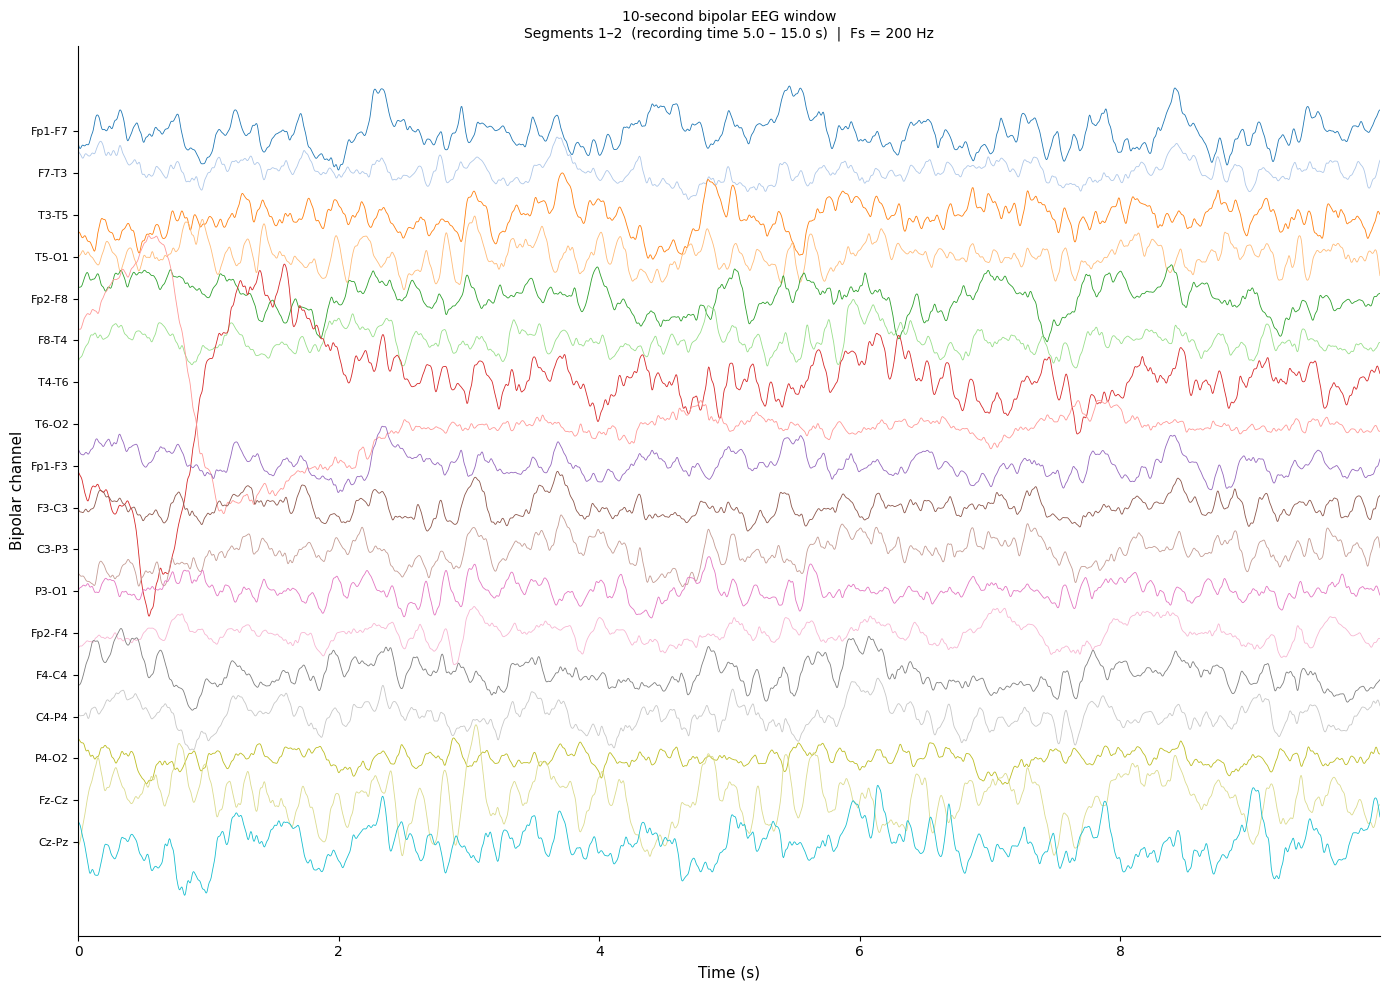

In [14]:
# ── Plotting parameters ────────────────────────────────────────────────────────
spacing_scale = 5.0   # Try changing this to spread or compress the traces
cmap = plt.cm.tab20   # One distinct colour per channel

# Robust amplitude estimate: median absolute deviation (MAD) collapsed per channel,
# then the median of those 18 MADs gives a single shared scale.
mad_per_channel = np.median(
    np.abs(eeg_10s - np.median(eeg_10s, axis=1, keepdims=True)),
    axis=1
)
spacing = float(np.median(mad_per_channel)) * spacing_scale
print(f'Vertical spacing between channels: {spacing:.2f} (data units)')

# ── Build the figure ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

for ch_idx in range(n_channels):
    # Top channel plotted highest: reverse index gives ascending y-offset
    offset = (n_channels - 1 - ch_idx) * spacing
    signal = eeg_10s[ch_idx]               # 1-D time series for this channel
    ax.plot(
        time_vec,
        signal + offset,
        linewidth=0.6,
        color=cmap(ch_idx / n_channels),
        rasterized=True                     # rasterize for faster rendering of dense traces
    )

# ── Y-axis: channel labels at the offset position of each trace ────────────────
ytick_positions = [(n_channels - 1 - i) * spacing for i in range(n_channels)]
ax.set_yticks(ytick_positions)
ax.set_yticklabels(channel_names, fontsize=8)

# ── Labels and title ───────────────────────────────────────────────────────────
ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('Bipolar channel', fontsize=11)

start_sec = seg_start_ids[chosen_seg] / Fs
ax.set_title(
    f'10-second bipolar EEG window\n'
    f'Segments {chosen_seg}–{chosen_seg + 1}  '
    f'(recording time {start_sec:.1f} – {start_sec + 10.0:.1f} s)  |  '
    f'Fs = {int(Fs)} Hz',
    fontsize=10
)

ax.set_xlim(time_vec[0], time_vec[-1])
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Summary and next steps

**What we found in this dataset:**

| Property | Value |
|---|---|
| Recording duration | ~13.9 hours |
| Sampling rate | 200 Hz |
| Signal representation | 10,000 non-overlapping 5-second bipolar EEG segments |
| Channels | 18 standard bipolar pairs (10-20 longitudinal montage) |
| Quality labels | `'normal'` (7,284 segments) plus artefact flags per segment |
| Pre-computed spectra | `EEG_specs` — 148 frequency bins per segment per channel |

**Things to explore or change:**
- Adjust `spacing_scale` in section 7 to change the vertical spread of the traces
- Replace `chosen_seg` with any other segment index to look at different parts of the recording
- Use `seg_labels.index('normal')` to find a later normal segment and check whether the EEG looks different

---

**Next tutorials:**
- **Tutorial 02** — Inspect and plot the pre-computed power spectra from `EEG_specs`
- **Tutorial 03** — Fit the aperiodic (1/f) component with `specparam` / FOOOF
- **Tutorial 04** — Track the aperiodic exponent across the full 13-hour recording